# Video classification with (2+1)D convolutional neural network

In [1]:
#!pip install opencv-python einops


In [2]:
import random
import cv2
import einops
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split 
from moviepy.video.io.VideoFileClip import VideoFileClip
import os

## Load and preprocess video data

In [3]:
path=r"D:\PROJECT DATASET\UCF50"
num_frames = 10 # Extract frames from the video.
img_size=(64,64)
classes=os.listdir(path)
len(classes)

50

In [4]:
class_10_list=classes[:10]
len(class_10_list)

10

In [5]:
def load_video(video_path, num_frames, img_size):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(total_frames // num_frames, 1)
    
    # Iterate through frames consecutively and capture at required intervals
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
        
        # Only process frames at the defined intervals
        if i % frame_interval == 0 and len(frames) < num_frames:
            frame = cv2.resize(frame, img_size)
            frames.append(frame)
    
    cap.release()
    
    # Pad with the last frame if there are less frames than required
    frames += [frames[-1]] * (num_frames - len(frames))

    return np.array(frames)

In [6]:
X=[]
y=[]
paths=[]
tf.random.set_seed(42)
for label,class_name in enumerate(class_10_list):
    class_path=os.path.join(path,class_name)
    for video_name in os.listdir(class_path):
        video_path=os.path.join(class_path,video_name)
        frames=load_video(video_path,num_frames,img_size)
        X.append(frames)
        y.append(label)
        paths.append(video_path)
X=np.array(X)
y=np.array(y)


In [7]:
X.shape

(1381, 10, 64, 64, 3)

In [8]:
y.shape

(1381,)

#### Train-test split

In [9]:
"""
#80% training, 10% validation and 10% testing.
# Split the dataset 
X_train,X_tmp,y_train,y_tmp=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_tmp,y_tmp,test_size=0.5,stratify=y_tmp,random_state=42)
"""
#80% training, 10% validation and 10% testing.
# Split the dataset 
X_train,X_tmp,y_train,y_tmp,train_path,tmp_path=train_test_split(X,y,paths,test_size=0.2,stratify=y,random_state=42)
X_val,X_test,y_val,y_test,val_path,test_path=train_test_split(X_tmp,y_tmp,tmp_path,test_size=0.5,stratify=y_tmp,random_state=42)

In [10]:
X_train.shape,X_val.shape,X_test.shape

((1104, 10, 64, 64, 3), (138, 10, 64, 64, 3), (139, 10, 64, 64, 3))

In [11]:
y_train.shape,y_val.shape,y_test.shape

((1104,), (138,), (139,))

## Model Architecture

In [12]:
#Define the dimensions of one frame in the set of frames created
h=64 #height
w=64 #weight

In [13]:
class Conv2Plus1D(tf.keras.layers.Layer):
  def __init__(self, filters, kernel_size, padding):
    """
      A sequence of convolutional layers that first apply the convolution operation over the
      spatial dimensions, and then the temporal dimension. 
    """
    super().__init__()
    self.seq = tf.keras.Sequential([  
        # Spatial decomposition
        tf.keras.layers.Conv3D(filters=filters,
                      kernel_size=(1, kernel_size[1], kernel_size[2]),
                      padding=padding),
        # Temporal decomposition
        tf.keras.layers.Conv3D(filters=filters, 
                      kernel_size=(kernel_size[0], 1, 1),
                      padding=padding)
        ])

  def call(self, x):
    return self.seq(x)

In [14]:
def add_residual_block(input,filters,kernel_size):
    out= Conv2Plus1D(filters=filters,kernel_size=kernel_size,padding='same')(input)
    out= tf.keras.layers.LayerNormalization()(out)
    out= tf.keras.layers.ReLU()(out)
    out= Conv2Plus1D(filters=filters,kernel_size=kernel_size,padding='same')(out)
    out=tf.keras.layers.LayerNormalization()(out)
    
    res=input
    if out.shape[-1]!=input.shape[-1]:
        units=out.shape[-1]
        res=tf.keras.layers.Dense(units)(res)
        res=tf.keras.layers.LayerNormalization()(res)
        
    return tf.keras.layers.add([res,out])

In [15]:
class ResizeVideo(tf.keras.layers.Layer):
  def __init__(self, height, width):
    super().__init__()
    self.height = height
    self.width = width
    self.resizing_layer = tf.keras.layers.Resizing(self.height, self.width)

  def call(self, video):
    """
      Use the einops library to resize the tensor.  

      Args:
        video: Tensor representation of the video, in the form of a set of frames.

      Return:
        A downsampled size of the video according to the new height and width it should be resized to.
    """
    # b stands for batch size, t stands for time, h stands for height, 
    # w stands for width, and c stands for the number of channels.
    old_shape = einops.parse_shape(video, 'b t h w c')
    images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
    images = self.resizing_layer(images)
    videos = einops.rearrange(
        images, '(b t) h w c -> b t h w c',
        t = old_shape['t'])
    return videos

In [16]:
input_shape=(None,10,h,w,3)
input=tf.keras.layers.Input(shape=(input_shape[1:]))
x=input
    
x=Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
x=tf.keras.layers.BatchNormalization()(x)
x=tf.keras.layers.ReLU()(x)
x=ResizeVideo(h//2,w//2)(x)

#Block1 
x=add_residual_block(x,16,(3,3,3))
x=ResizeVideo(h//4,w//4)(x)

#Block 2
x=add_residual_block(x,32,(3,3,3))
x=ResizeVideo(h//8,w//8)(x)

#Block 3
x=add_residual_block(x,64,(3,3,3))
x=ResizeVideo(h//16,w//16)(x)

#Block 4
x=add_residual_block(x,128,(3,3,3))

x=tf.keras.layers.GlobalAveragePooling3D()(x)
#x=tf.keras.layers.Flatten()(x)
x=tf.keras.layers.Dense(10,activation='softmax')(x)

model=tf.keras.Model(input,x,name='Conv2Plus1D')
model.build(X_train)


In [17]:
model.summary()

Model: "Conv2Plus1D"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 10, 64, 64, 3)]      0         []                            
                                                                                                  
 conv2_plus1d (Conv2Plus1D)  (None, 10, 64, 64, 16)       3152      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 10, 64, 64, 16)       64        ['conv2_plus1d[0][0]']        
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 10, 64, 64, 16)       0         ['batch_normalizatio

### Model Training 

In [18]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [19]:
history=model.fit(X_train,y_train,epochs=50,validation_data=(X_val,y_val),batch_size=32)

Epoch 1/50


35/35 [==============================] - 56s 1s/step - loss: 2.1127 - accuracy: 0.3071 - val_loss: 2.1449 - val_accuracy: 0.2826
Epoch 2/50
35/35 [==============================] - 41s 1s/step - loss: 1.3849 - accuracy: 0.5045 - val_loss: 1.2717 - val_accuracy: 0.5797
Epoch 3/50
35/35 [==============================] - 40s 1s/step - loss: 1.1506 - accuracy: 0.5806 - val_loss: 1.1430 - val_accuracy: 0.5725
Epoch 4/50
35/35 [==============================] - 39s 1s/step - loss: 0.9756 - accuracy: 0.6377 - val_loss: 1.3304 - val_accuracy: 0.5362
Epoch 5/50
35/35 [==============================] - 39s 1s/step - loss: 0.8439 - accuracy: 0.6848 - val_loss: 0.9194 - val_accuracy: 0.6594
Epoch 6/50
35/35 [==============================] - 39s 1s/step - loss: 0.7608 - accuracy: 0.7219 - val_loss: 0.6812 - val_accuracy: 0.7899
Epoch 7/50
35/35 [==============================] - 40s 1s/step - loss: 0.6541 - accuracy: 0.7790 - val_loss: 0.6906 - val_accuracy: 0.7319
Epoch 8/50
35/35 [

## Plotting the Accuracy and Loss

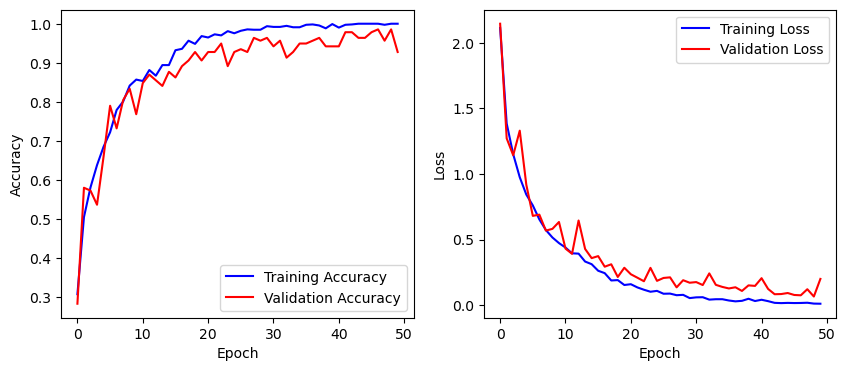

In [20]:
fig,ax=plt.subplots(1,2,figsize=(10,4))

ax[0].plot(range(50),history.history['accuracy'],color='blue',label='Training Accuracy')
ax[0].plot(range(50),history.history['val_accuracy'],color='red',label='Validation Accuracy')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(range(50),history.history['loss'],color='blue',label='Training Loss')
ax[1].plot(range(50),history.history['val_loss'],color='red',label='Validation Loss')
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.show()


## Model Evaluation 

In [21]:
model.evaluate(X_test,y_test)

5/5 [==============================] - 2s 320ms/step - loss: 0.1130 - accuracy: 0.9640


[0.11303556710481644, 0.9640287756919861]

In [22]:
set(y_test)


{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

## Plotting Confusion matrix for testing set

In [23]:
def plot_confusion_matrix(actual, predicted, labels, ds_type):
    cm = tf.math.confusion_matrix(actual, predicted)
    sns.heatmap(cm, annot=True, fmt='g', xticklabels=labels, yticklabels=labels, 
                cmap="Blues", cbar=False)
    plt.title(f'Confusion Matrix of Action Recognition for {ds_type}')
    plt.xlabel('Predicted Action')
    plt.ylabel('Actual Action')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

In [24]:
#ground_truth_test=np.array([y_test[i] for i in range(y_test.shape[0])])
ground_truth_test=y_test.copy()
predicted_test=model.predict(X_test)

5/5 [==============================] - 3s 312ms/step


In [25]:
predicted_test.shape

(139, 10)

In [26]:
ground_truth_test.shape


(139,)

In [27]:
predicted_test=tf.concat(predicted_test,axis=0)
predicted_test=np.argmax(predicted_test,axis=1)



In [28]:
ground_truth_test

array([1, 4, 2, 6, 7, 5, 8, 8, 8, 2, 0, 8, 2, 5, 4, 7, 0, 7, 7, 3, 3, 8,
       8, 1, 2, 0, 9, 2, 0, 9, 7, 3, 5, 9, 8, 1, 1, 4, 1, 0, 2, 1, 4, 0,
       8, 5, 9, 6, 8, 2, 5, 3, 8, 0, 6, 2, 7, 2, 2, 2, 1, 5, 5, 4, 4, 6,
       7, 1, 3, 9, 5, 1, 4, 1, 4, 8, 4, 4, 8, 5, 3, 2, 5, 6, 0, 0, 0, 1,
       4, 6, 6, 7, 9, 9, 9, 9, 1, 1, 2, 0, 1, 8, 2, 3, 7, 3, 6, 6, 7, 0,
       4, 7, 0, 8, 7, 8, 3, 0, 7, 7, 3, 7, 3, 0, 4, 2, 3, 3, 9, 9, 3, 8,
       4, 3, 6, 2, 4, 7, 6])

In [29]:
predicted_test

array([1, 4, 2, 6, 7, 5, 8, 8, 8, 2, 0, 8, 2, 5, 4, 7, 0, 7, 7, 3, 3, 8,
       8, 1, 2, 0, 9, 2, 0, 9, 7, 3, 5, 9, 8, 1, 1, 4, 1, 0, 2, 1, 4, 0,
       8, 5, 9, 6, 8, 8, 5, 3, 8, 0, 6, 2, 7, 2, 2, 2, 1, 5, 5, 4, 4, 6,
       7, 1, 3, 9, 5, 1, 4, 1, 4, 8, 4, 4, 8, 5, 3, 2, 5, 6, 0, 0, 0, 1,
       4, 6, 6, 7, 9, 9, 9, 9, 5, 1, 2, 0, 1, 8, 2, 3, 7, 3, 6, 6, 3, 0,
       4, 7, 0, 8, 7, 8, 3, 0, 7, 7, 3, 5, 9, 0, 4, 2, 3, 3, 9, 9, 3, 8,
       4, 3, 6, 2, 4, 7, 6], dtype=int64)

In [90]:
np.array(list(predicted_test-ground_truth_test))

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  4,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0, -4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -2,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0], dtype=int64)

In [30]:
labels=class_10_list

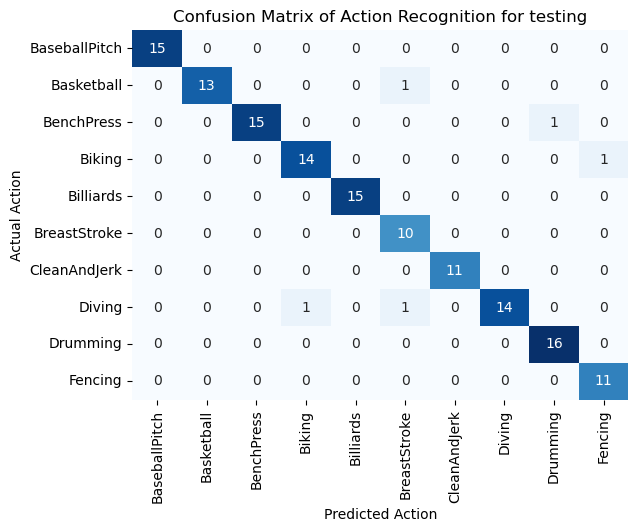

In [31]:
plot_confusion_matrix(ground_truth_test, predicted_test, labels, 'testing')

In [32]:
def calculate_classification_metrics(y_actual, y_pred, labels):
  """
    Calculate the precision and recall of a classification model using the ground truth and
    predicted values. 

    Args:
      y_actual: Ground truth labels.
      y_pred: Predicted labels.
      labels: List of classification labels.

    Return:
      Precision and recall measures.
  """
  cm = tf.math.confusion_matrix(y_actual, y_pred)
  tp = np.diag(cm) # Diagonal represents true positives
  precision = dict()
  recall = dict()
  for i in range(len(labels)):
    col = cm[:, i]
    fp = np.sum(col) - tp[i] # Sum of column minus true positive is false positive.

    row = cm[i, :]
    fn = np.sum(row) - tp[i] # Sum of row minus true positive, is false negative.

    precision[labels[i]] = tp[i] / (tp[i] + fp) # Precision 

    recall[labels[i]] = tp[i] / (tp[i] + fn) # Recall

  return precision, recall

In [33]:
precision, recall = calculate_classification_metrics(ground_truth_test, predicted_test, labels) # Test dataset

In [34]:
precision

{'BaseballPitch': 1.0,
 'Basketball': 1.0,
 'BenchPress': 1.0,
 'Biking': 0.9333333333333333,
 'Billiards': 1.0,
 'BreastStroke': 0.8333333333333334,
 'CleanAndJerk': 1.0,
 'Diving': 1.0,
 'Drumming': 0.9411764705882353,
 'Fencing': 0.9166666666666666}

In [35]:
recall

{'BaseballPitch': 1.0,
 'Basketball': 0.9285714285714286,
 'BenchPress': 0.9375,
 'Biking': 0.9333333333333333,
 'Billiards': 1.0,
 'BreastStroke': 1.0,
 'CleanAndJerk': 1.0,
 'Diving': 0.875,
 'Drumming': 1.0,
 'Fencing': 1.0}

## Saving few predicted test video with labels

In [65]:
labels

['BaseballPitch',
 'Basketball',
 'BenchPress',
 'Biking',
 'Billiards',
 'BreastStroke',
 'CleanAndJerk',
 'Diving',
 'Drumming',
 'Fencing']

In [66]:
y_test


array([1, 4, 2, 6, 7, 5, 8, 8, 8, 2, 0, 8, 2, 5, 4, 7, 0, 7, 7, 3, 3, 8,
       8, 1, 2, 0, 9, 2, 0, 9, 7, 3, 5, 9, 8, 1, 1, 4, 1, 0, 2, 1, 4, 0,
       8, 5, 9, 6, 8, 2, 5, 3, 8, 0, 6, 2, 7, 2, 2, 2, 1, 5, 5, 4, 4, 6,
       7, 1, 3, 9, 5, 1, 4, 1, 4, 8, 4, 4, 8, 5, 3, 2, 5, 6, 0, 0, 0, 1,
       4, 6, 6, 7, 9, 9, 9, 9, 1, 1, 2, 0, 1, 8, 2, 3, 7, 3, 6, 6, 7, 0,
       4, 7, 0, 8, 7, 8, 3, 0, 7, 7, 3, 7, 3, 0, 4, 2, 3, 3, 9, 9, 3, 8,
       4, 3, 6, 2, 4, 7, 6])

In [67]:
predicted_test

array([1, 4, 2, 6, 7, 5, 8, 8, 8, 2, 0, 8, 2, 5, 4, 7, 0, 7, 7, 3, 3, 8,
       8, 1, 2, 0, 9, 2, 0, 9, 7, 3, 5, 9, 8, 1, 1, 4, 1, 0, 2, 1, 4, 0,
       8, 5, 9, 6, 8, 8, 5, 3, 8, 0, 6, 2, 7, 2, 2, 2, 1, 5, 5, 4, 4, 6,
       7, 1, 3, 9, 5, 1, 4, 1, 4, 8, 4, 4, 8, 5, 3, 2, 5, 6, 0, 0, 0, 1,
       4, 6, 6, 7, 9, 9, 9, 9, 5, 1, 2, 0, 1, 8, 2, 3, 7, 3, 6, 6, 3, 0,
       4, 7, 0, 8, 7, 8, 3, 0, 7, 7, 3, 5, 9, 0, 4, 2, 3, 3, 9, 9, 3, 8,
       4, 3, 6, 2, 4, 7, 6], dtype=int64)

In [221]:
abs(y_test-predicted_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [202]:
import cv2
import numpy as np
from collections import deque

def save_predicted_video(index,video_file_path, output_file_path, SEQUENCE_LENGTH,labels, img_size):
    # Initialize the VideoCapture object to read from the video file.
    video_reader = cv2.VideoCapture(video_file_path)
    # Get the width and height of the video.
    original_video_width = int(video_reader.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_video_height = int(video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT))
    # Initialize the VideoWriter object to store the output video on disk.
    video_writer = cv2.VideoWriter(output_file_path, cv2.VideoWriter_fourcc(*'mp4v'),
                                   video_reader.get(cv2.CAP_PROP_FPS), (original_video_width, original_video_height))
    # Declare a queue to store video frames.
    frames_queue = deque(maxlen=SEQUENCE_LENGTH)
    # Initialize a variable to store the predicted action being performed in the video.
    predicted_class_name = ''
    # Iterate until the video is accessed successfully.
    while video_reader.isOpened():
        # Read the frame.
        ok, frame = video_reader.read()
        # Check if the frame is not read properly, then break the loop.
        if not ok:
            break
        # Resize the frame to fixed dimensions.
        resized_frame = cv2.resize(frame, (img_size[0], img_size[1]))
        # Normalize the resized frame by dividing by 255 so that each pixel value then lies between 0 and 1.
        normalized_frame = resized_frame / 255.0
        # Append the pre-processed frame into the frames queue.
        frames_queue.append(normalized_frame)
        # Check if the number of frames in the queue are equal to the fixed sequence length.
        if len(frames_queue) == SEQUENCE_LENGTH:
            predicted_label = predicted_test[index]
            # Get the class name using the retrieved index.
            predicted_class_name = labels[predicted_label]
            target_label=y_test[index]
            target_class_name=labels[target_label]
        # Write predicted class name on top of the frame.
        cv2.putText(frame, predicted_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        # Write the frame into the disk using the VideoWriter Object.
        video_writer.write(frame)
    # Release the VideoCapture and VideoWriter objects.
    video_reader.release()
    video_writer.release()  
    print(f"Target Class name: {target_class_name},  Predicted Class name: {predicted_class_name}")
    
    
    



In [206]:
outputs=[]
for i in range(115,len(predicted_test)):
    input_video_file_path=test_path[i]
    input=input_video_file_path.split('\\')[-1][:-4]
    SEQUENCE_LENGTH=num_frames
    # Construct the output video path.
    output_video_file_path=f'video_test_outputs/{input}.Output.SeqLen{SEQUENCE_LENGTH}_{labels[predicted_test[i]]}.mp4'
    save_predicted_video(i,input_video_file_path,output_video_file_path,SEQUENCE_LENGTH,labels,img_size)
    #Display the output video.
    VideoFileClip(output_video_file_path,audio=False,target_resolution=(600,None))
    outputs.append(output_video_file_path)
    

Target Class name: Drumming,  Predicted Class name: Drumming
Target Class name: Biking,  Predicted Class name: Biking
Target Class name: BaseballPitch,  Predicted Class name: BaseballPitch
Target Class name: Diving,  Predicted Class name: Diving
Target Class name: Diving,  Predicted Class name: Diving
Target Class name: Biking,  Predicted Class name: Biking
Target Class name: Diving,  Predicted Class name: BreastStroke
Target Class name: Biking,  Predicted Class name: Fencing
Target Class name: BaseballPitch,  Predicted Class name: BaseballPitch
Target Class name: Billiards,  Predicted Class name: Billiards
Target Class name: BenchPress,  Predicted Class name: BenchPress
Target Class name: Biking,  Predicted Class name: Biking
Target Class name: Biking,  Predicted Class name: Biking
Target Class name: Fencing,  Predicted Class name: Fencing
Target Class name: Fencing,  Predicted Class name: Fencing
Target Class name: Biking,  Predicted Class name: Biking
Target Class name: Drumming,  P